<a href="https://colab.research.google.com/github/Sofiacesari/Estrategia-de-Retenci-n-en-E-commerce-Recomendaci-n-de-Productos-Similares/blob/main/HYM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo práctico final obligatorio - Sofía Odette Cesari HYM


# Selección del dataset y objetivos

Los datos utilizados en este proyecto provienen del desafío público "H&M Personalized Fashion Recommendations" alojado en la plataforma Kaggle. El dataset original fue proporcionado por el Grupo H&M para fines de investigación y desarrollo de modelos de recomendación en la industria de la moda. Puede encontrase en: https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations/data

La elección de este dataset y la problemática asociada se basa en los siguientes puntos de interés:


- **Problemática de Negocio Real:** En el entorno del e-commerce, uno de los mayores puntos de fricción es el "Out of Stock". Cuando un cliente encuentra un producto agotado, la probabilidad de abandono del sitio es alta. Este proyecto busca resolver dicha problemática mediante un sistema de recomendación técnica.


- **Valor Estratégico:** El desarrollo de un buscador de productos similares permite retener al usuario ofreciéndole alternativas que compartan características idénticas (mismo tipo de prenda, mismo color y misma estampa). Esto impacta directamente en la conversión de ventas y en la satisfacción del cliente.

# Carga de datos

In [ ]:
# Importación de librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:

df=pd.read_csv('/content/articles.csv')

In [ ]:
df


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105537,953450001,953450,5pk regular Placement1,302,Socks,Socks & Tights,1010014,Placement print,9,Black,...,Socks Bin,F,Menswear,3,Menswear,26,Men Underwear,1021,Socks and Tights,Socks in a fine-knit cotton blend with a small...
105538,953763001,953763,SPORT Malaga tank,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey,A,Ladieswear,1,Ladieswear,2,H&M+,1005,Jersey Fancy,Loose-fitting sports vest top in ribbed fast-d...
105539,956217002,956217,Cartwheel dress,265,Dress,Garment Full body,1010016,Solid,9,Black,...,Jersey,A,Ladieswear,1,Ladieswear,18,Womens Trend,1005,Jersey Fancy,"Short, A-line dress in jersey with a round nec..."
105540,957375001,957375,CLAIRE HAIR CLAW,72,Hair clip,Accessories,1010016,Solid,9,Black,...,Small Accessories,D,Divided,2,Divided,52,Divided Accessories,1019,Accessories,Large plastic hair claw.


# Dicciónario de variables



    








| Variable | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| **article_id** | `int64` | Identificador único numérico del producto (10 dígitos). |
| **product_code** | `int64` | Identificador numérico del modelo base (diseño). |
| **prod_name** | `object` | Nombre comercial del producto. |
| **product_type_no** | `int64` | Código numérico del tipo de prenda. |
| **product_type_name** | `object` | Descripción de la categoría de prenda (ej: T-shirt). |
| **product_group_name** | `object` | Categoría macro del producto (ej: Garment Upper body). |
| **graphical_appearance_no** | `int64` | Código numérico de la estampa o textura. |
| **graphical_appearance_name** | `object` | Descripción de la estampa (ej: Solid, Floral). |
| **colour_group_code** | `int64` | Código numérico del grupo de color. |
| **perceived_colour_value_id** | `int64` | Identificador númerico para el color percibido del producto. |
| **perceived_colour_value_name** | `object` | Nombre del color percibido del producto. |
| **perceived_colour_master_id** | `int64` | Identificador númerico de la categoria generalizada del color percibido. |
| **perceived_colour_master_name** | `object` | Nombre de la categoria generalizada del color percibido. |
| **department_no** | `int64` | Identificador númerico del departamento al que corresponde el producto. |
| **department_name** | `object` | Nombre del departamento al que corresponde el producto. |
| **index_code** | `object` | Identificador alfabético de la categora a la que pertenece el producto.|
| **index_name** | `object` | Categoria a la que pertenece el producto.|
| **index_group_no** | `int64` | Identificador númerico de la categoria general a la cual pertenece el producto.|
| **index_group_name** | `object` | Categoria general a la cual pertenece el producto.|
| **section_name** | `object` | Sección de la tienda donde pertenece el producto.|
| **garment_group_no** | `int64` | Identificador númerico de la familia general de la prenda a la que pertenece el producto.|
| **garment_group_name** | `object` | Familia general de la prenda a la que pertenece el producto.|
| **detail_desc** | `object` | Descripción detallada de las caracteristicas del producto.|

# Limpieza de datos


In [ ]:
print(df.isna().sum())

print(df.duplicated().sum())

print(df.dtypes)

df['prod_name'].map(type).value_counts(normalize=True) * 100

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64
0
article_id                       int64
product_code                     int64
prod_na

,proportion
prod_name,
<class 'str'>,100.0


Para garantizar la integridad del modelo de recomendación, se realizó un proceso de auditoría y limpieza sobre el dataset original. Se ejecutaron las siguientes validaciones técnicas:

**Detección de valores faltantes:** Se utilizó la función isna().sum(), arrojando como resultado que ninguna de las columnas críticas para el modelo (como article_id, product_type_no o colour_group_code) presenta valores nulos. Al contar con un dataset completo, se decidió conservar la totalidad de los registros.

**Control de redundancia:** Mediante duplicated().sum(), se verificó la existencia de filas repetidas. El resultado fue 0, confirmando que cada article_id representa una variante de producto única y no hay registros duplicados que puedan distorsionar el análisis estadístico o el entrenamiento.

** Verificación de tipos de datos **: Se comprobó con dtypes que las variables identificadoras y categóricas numéricas están correctamente formateadas como int64.

**Consistencia de nombres:** Se analizó la columna prod_name para asegurar que todos los registros fueran de tipo string. Se obtuvo un 100% de consistencia, descartando la presencia de valores erróneos o tipos de datos mixtos en los nombres de los productos.

Dado que el dataset no presenta valores nulos, duplicados ni inconsistencias de tipo, se procedió a trabajar con la base de datos íntegra.

In [ ]:
def inspect_col(col):
  return (
      col.map(type)
      .value_counts()
      .rename("count")
      .to_frame()
      .assign(percent=lambda x: x / x.sum()*100)
  )

In [ ]:
import pandas as pd

results = []
for col_name in df.columns:
    inspection_df = inspect_col(df[col_name])
    inspection_df = inspection_df.reset_index()
    inspection_df.columns = ['type', 'count', 'percent']
    inspection_df['column_name'] = col_name
    results.append(inspection_df)

if results:
    combined_df = pd.concat(results).set_index(['column_name', 'type'])
    print("\nInspección consolidada de tipos de datos por columna:")
    display(combined_df)
else:
    print("No se encontraron columnas para inspeccionar.")


Inspección consolidada de tipos de datos por columna:


,,count,percent
column_name,type,,
article_id,<class 'int'>,105542,100.000000
product_code,<class 'int'>,105542,100.000000
prod_name,<class 'str'>,105542,100.000000
product_type_no,<class 'int'>,105542,100.000000
product_type_name,<class 'str'>,105542,100.000000
product_group_name,<class 'str'>,105542,100.000000
graphical_appearance_no,<class 'int'>,105542,100.000000
graphical_appearance_name,<class 'str'>,105542,100.000000
colour_group_code,<class 'int'>,105542,100.000000


Adicionalmente, se desarrolló e implementó una función personalizada de inspección de tipos a nivel de registro (inspect_col). Esta técnica permitió validar que columnas críticas como prod_name y detail_desc mantienen una consistencia absoluta en sus tipos de datos (100% strings), descartando la presencia de datos mixtos que pudieran afectar el procesamiento de lenguaje natural o la lógica del modelo de recomendación.

In [ ]:
df[df["detail_desc"].map(type) == float]

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
1467,351332007,351332,Marshall Lace up Top,252,Sweater,Garment Upper body,1010018,Treatment,7,Grey,...,Jersey Fancy DS,D,Divided,2,Divided,58,Divided Selected,1005,Jersey Fancy,NaN
2644,420049002,420049,OL TAGE PQ,87,Boots,Shoes,1010016,Solid,13,Beige,...,Premium Quality,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,NaN
2645,420049003,420049,OL TAGE PQ,87,Boots,Shoes,1010016,Solid,23,Dark Yellow,...,Premium Quality,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,NaN
2742,426199002,426199,Ellen Shortie Daisy Low 3p,286,Underwear bottom,Underwear,1010016,Solid,9,Black,...,Casual Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear",NaN
2743,426199010,426199,Ellen Shortie Daisy Low 3p,286,Underwear bottom,Underwear,1010017,Stripe,8,Dark Grey,...,Casual Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67838,752458001,752458,Poissy boho dress,265,Dress,Garment Full body,1010007,Embroidery,10,White,...,Dress,A,Ladieswear,1,Ladieswear,6,Womens Casual,1013,Dresses Ladies,NaN
72720,768842001,768842,Andrews set,270,Garment Set,Garment Full body,1010017,Stripe,10,White,...,Baby Boy Woven,G,Baby Sizes 50-98,4,Baby/Children,41,Baby Boy,1006,Woven/Jersey/Knitted mix Baby,NaN
72721,768842004,768842,Andrews set,270,Garment Set,Garment Full body,1010004,Check,73,Dark Blue,...,Baby Boy Woven,G,Baby Sizes 50-98,4,Baby/Children,41,Baby Boy,1006,Woven/Jersey/Knitted mix Baby,NaN
93144,856985001,856985,Pogo rope,67,Belt,Accessories,1010016,Solid,12,Light Beige,...,Belts,C,Ladies Accessories,1,Ladieswear,65,Womens Big accessories,1019,Accessories,NaN


In [ ]:
df["detail_desc"] = (
    df["detail_desc"]
    .astype("string")
    .fillna("non_defined")
)

inspect_col(df["detail_desc"])

,count,percent
detail_desc,,
<class 'str'>,105542,100.0


Se identificó que la variable detail_desc contenía registros con valores nulos, detectados mediante un mapeo de tipos (float). Dado que la descripción es una característica valiosa pero no indispensable para el cálculo de distancias numéricas, se optó por una estrategia de imputación. Se convirtieron los registros a tipo string y se completaron los valores faltantes con la etiqueta 'non_defined'. Esto permitió mantener la integridad del dataset original sin perder artículos valiosos para el sistema de recomendación.

# Exploración inicial

1. ¿Qué tipo de ropa vende más H&M? (Macro-categorías)


In [ ]:
df['product_group_name'].value_counts()

,count
product_group_name,
Garment Upper body,42741
Garment Lower body,19812
Garment Full body,13292
Accessories,11158
Underwear,5490
Shoes,5283
Swimwear,3127
Socks & Tights,2442
Nightwear,1899


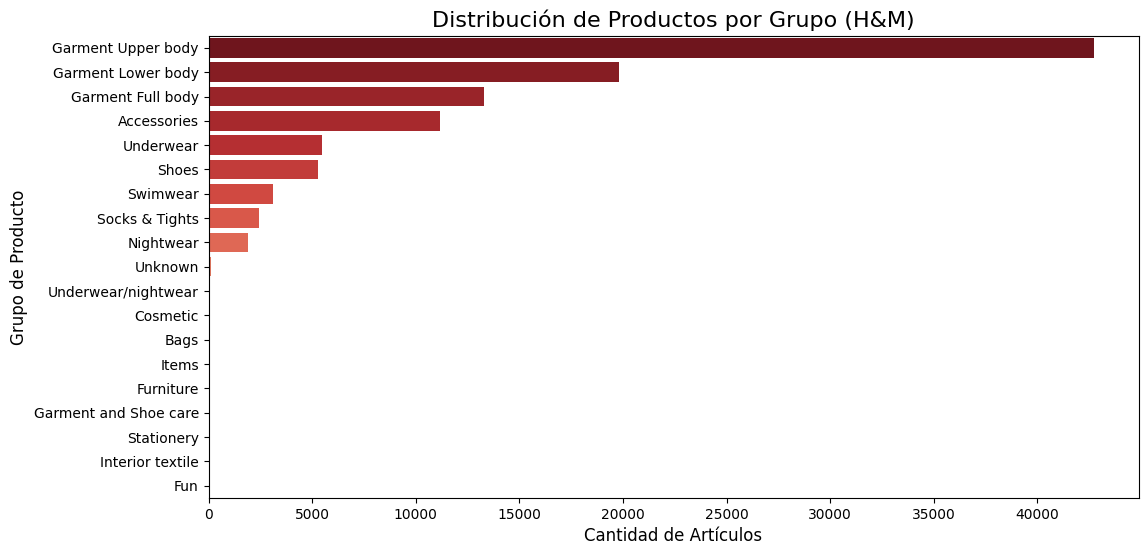

In [ ]:
conteo_grupos = df['product_group_name'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(
    x=conteo_grupos.values,
    y=conteo_grupos.index,
    hue=conteo_grupos.index,
    palette='Reds_r',
    legend=False
)

plt.title('Distribución de Productos por Grupo (H&M)', fontsize=16)
plt.xlabel('Cantidad de Artículos', fontsize=12)
plt.ylabel('Grupo de Producto', fontsize=12);


2. ¿Para quién es la ropa? (Segmentos de Mercado)


In [ ]:
df['index_group_name'].value_counts()

,count
index_group_name,
Ladieswear,39737
Baby/Children,34711
Divided,15149
Menswear,12553
Sport,3392


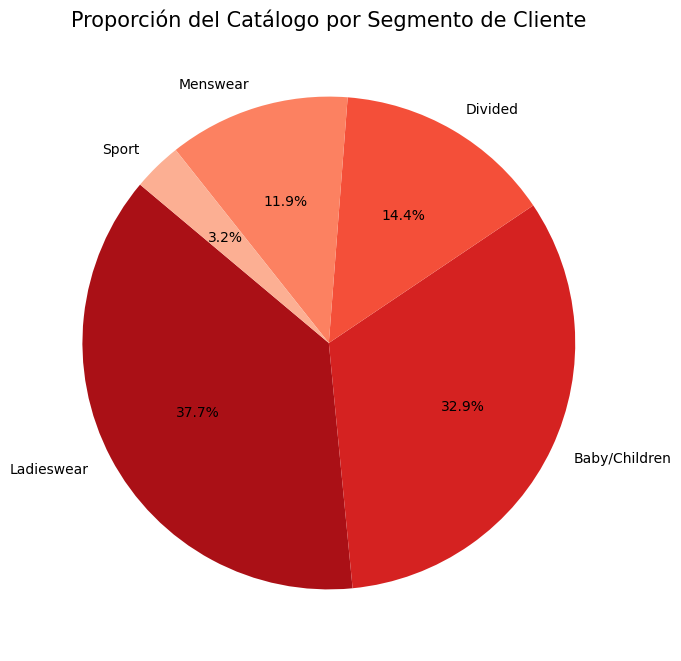

In [ ]:
conteo_index = df['index_group_name'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(
    conteo_index.values,
    labels=conteo_index.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Reds_r')
)
plt.title('Proporción del Catálogo por Segmento de Cliente', fontsize=15);

Este gráfico justifica por qué vas a tener muchos resultados para ropa de mujer y niños, y quizás menos para ropa deportiva.

3. El Arcoíris de H&M (Top Colores)

In [ ]:
df['colour_group_name'].value_counts()

,count
colour_group_name,
Black,22670
Dark Blue,12171
White,9542
Light Pink,5811
Grey,4487
Light Beige,3356
Blue,3308
Red,3056
Light Blue,3012


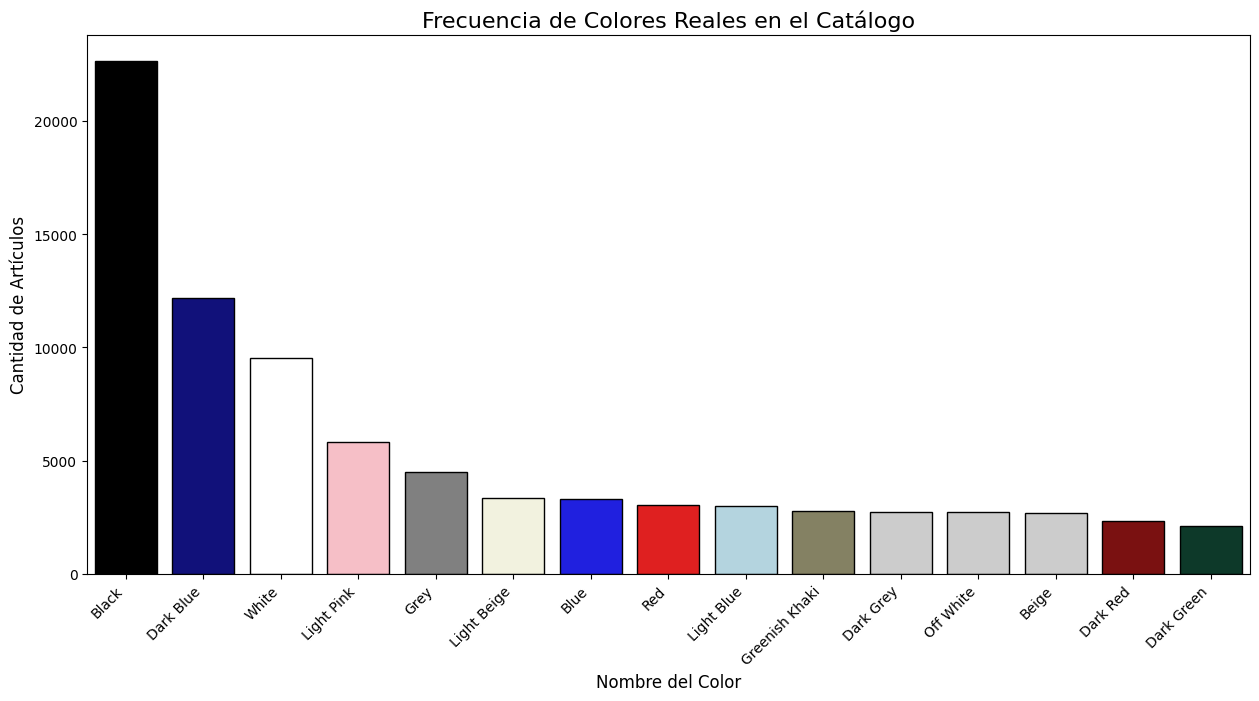

In [ ]:
conteo_colores = df['colour_group_name'].value_counts().head(15)
mapeo_colores = {
    'Black': '#000000',
    'Dark Blue': '#00008B',
    'White': '#FFFFFF',
    'Light Pink': '#FFB6C1',
    'Grey': '#808080',
    'Blue': '#0000FF',
    'Dark Green': '#006400',
    'Light Blue': '#ADD8E6',
    'Red': '#FF0000',
    'Greenish Khaki': '#8A865D',
    'Dark Red': '#8B0000',
    'Light Grey': '#D3D3D3',
    'Dark Green': '#06402B',
    'Light Beige': '#F5F5DC',
    'Pink': '#F64A8A',
}
colores_finales = [mapeo_colores.get(color, '#CCCCCC') for color in conteo_colores.index]
plt.figure(figsize=(15, 7))
ax = sns.barplot(
    x=conteo_colores.index,
    y=conteo_colores.values,
    hue=conteo_colores.index,
    palette=colores_finales,
    legend=False,
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right')
plt.title('Frecuencia de Colores Reales en el Catálogo', fontsize=16)
plt.xlabel('Nombre del Color', fontsize=12)
plt.ylabel('Cantidad de Artículos', fontsize=12);

¿Liso o Estampado? (Apariencia Gráfica)

In [ ]:
df['graphical_appearance_name'].value_counts()

,count
graphical_appearance_name,
Solid,49747
All over pattern,17165
Melange,5938
Stripe,4990
Denim,4842
Front print,3215
Placement print,3098
Check,2178
Colour blocking,1830


In [ ]:
conteo_apariencia = df['graphical_appearance_name'].value_counts().head(15)

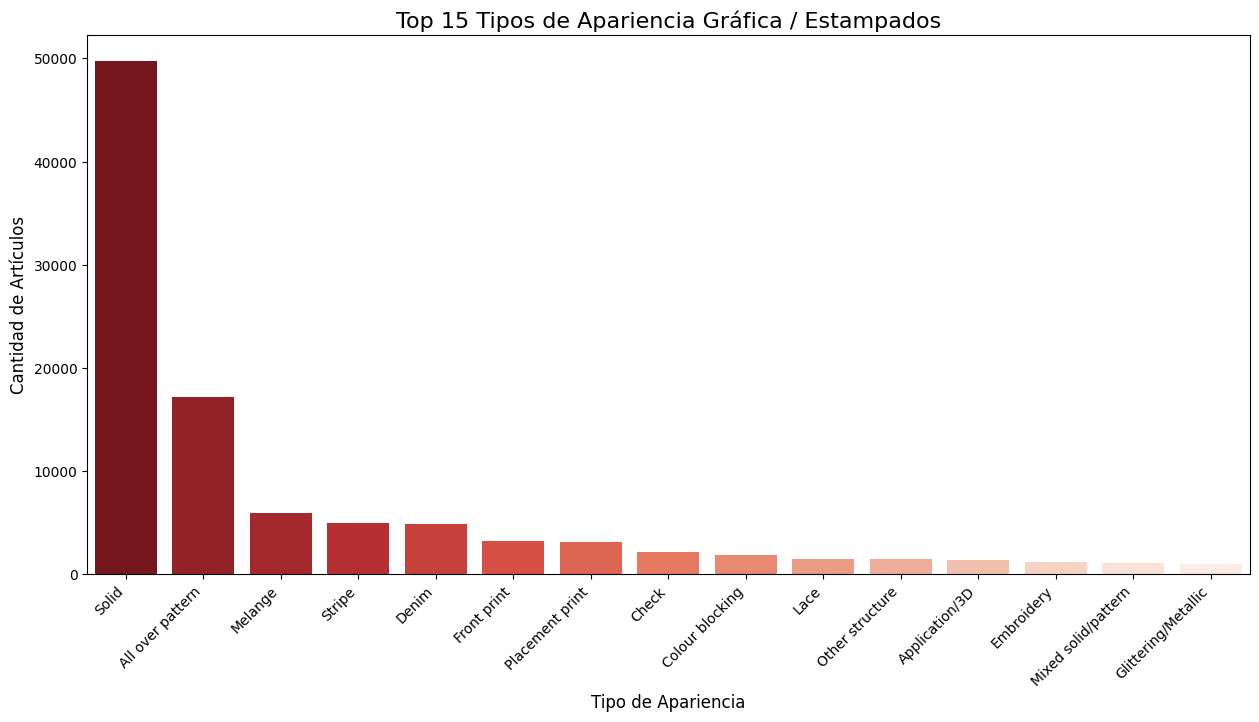

In [ ]:
conteo_apariencia = df['graphical_appearance_name'].value_counts().head(15)
plt.figure(figsize=(15, 7))
sns.barplot(
    x=conteo_apariencia.index,
    y=conteo_apariencia.values,
    hue=conteo_apariencia.index,
    palette='Reds_r',
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Tipos de Apariencia Gráfica / Estampados', fontsize=16)
plt.xlabel('Tipo de Apariencia', fontsize=12)
plt.ylabel('Cantidad de Artículos', fontsize=12);

Quiero saber cuanto son lisos y cuantos estampados en general


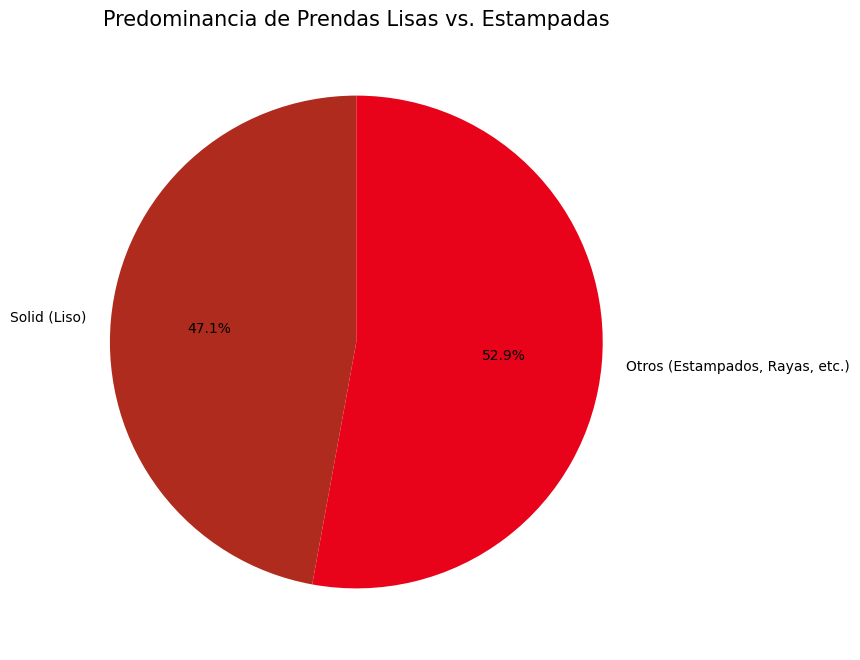

In [ ]:
conteo_todas = df['graphical_appearance_name'].value_counts()
cantidad_solid = conteo_todas['Solid']
cantidad_otros = conteo_todas.sum() - cantidad_solid
datos_agrupados = [cantidad_solid, cantidad_otros]
etiquetas = ['Solid (Liso)', 'Otros (Estampados, Rayas, etc.)']
plt.figure(figsize=(8, 8))
plt.pie(
    datos_agrupados,
    labels=etiquetas,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#AF2B1E', '#E8031B'],
)

plt.title('Predominancia de Prendas Lisas vs. Estampadas', fontsize=15);

## 6. Definición del problema y modelo ##


1. **Definición del problema:** El problema central que aborda este proyecto es la pérdida de conversión por falta de stock (Out of Stock) en la plataforma e-commerce de H&M.Cuando un cliente busca un artículo específico y este no se encuentra disponible, la tendencia natural es el abandono del sitio, lo que se traduce en una venta perdida y una disminución en la fidelidad del usuario. El desafío consiste en transformar este "punto de fricción" en una oportunidad de venta, mediante un sistema capaz de identificar y proponer automáticamente productos sustitutos que mantengan las características visuales y técnicas del artículo agotado.
2.** Selección del modelo de Machine Learning**: Para abordar este problema, se ha seleccionado el modelo de K-Nearest Neighbors (KNN) o "K-Vecinos más Cercanos".
3. **Justificación del modelo:** El modelo KNN es el más apropiado para este sistema de recomendación por las siguientes razones:

*   **Naturaleza de la similitud:** KNN es un algoritmo basado en la proximidad. En el contexto de la moda, un producto "similar" es aquel que se encuentra "cerca" de otro en un espacio multidimensional definido por atributos como el color, el tipo de prenda y el estampado.
*  **Aprendizaje No Supervisado:** Dado que no buscamos predecir un valor futuro (como un precio), sino encontrar relaciones de semejanza entre los artículos existentes, un modelo de agrupación por distancia como KNN es ideal.Interpretabilidad: El modelo permite ajustar cuántos "vecinos" (sustitutos) queremos mostrar al cliente (por ejemplo, $k=5$), asegurando que las alternativas presentadas sean matemáticamente las más parecidas al producto original.
* **Eficiencia con datos numéricos:** Como el dataset de H&M ya provee identificadores numéricos para las categorías visuales, el modelo KNN puede calcular distancias euclidianas de forma veloz, permitiendo recomendaciones en tiempo real.

## 7. Selección de características ##


Para que el modelo de K-Nearest Neighbors (KNN) pueda calcular la similitud entre productos, es necesario seleccionar las variables que mejor describen la "identidad" de una prenda. Basándonos en el Análisis Exploratorio de Datos (EDA) realizado en el Punto 4, hemos seleccionado las siguientes características numéricas:

**1.product_type_no:** Identificador numérico de la categoría de prenda. Es el filtro principal para asegurar que el sustituto sea funcionalmente igual (ej. recomendar un pantalón por otro pantalón).
**2.graphical_appearance_no**